# just for thalamus

In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\utils'))
sys.path.append(os.path.join(now_dir, r'models\thalamus'))
sys.path.append(os.path.join(now_dir, r'models\demo_model'))

d:\mynew\demo_all


In [2]:

import pypet as pp 
import numpy as np 

# utils libs
import runModels as rm 
'''
parametrization_demo = pp.cartesian_product({
    'g_h': [float(round(elem, 3)) for elem in np.linspace(0.0, 0.08, 20)],
    'g_LK': [float(round(elem, 3)) for elem in np.linspace(0.0, 0.08, 20)],
    'model': ['thalamus']
}) # {'a': [...], 'b': [...], 'model': [...]}
parametrization_demo = pp.cartesian_product({
    'g_h': [round(elem, 3) for elem in [0.0, 0.01, 0.02]],
    'g_LK': [round(elem, 3) for elem in [0.0, 0.01, 0.02]],
    'model': ['thalamus']
})
type(parametrization_demo['g_h'][0]) # np.linspace will cause the type of number to be np.float64, which is conflicted with later computation?
'''

parametrization_demo = pp.cartesian_product({
    'g_h': [float(round(elem, 3)) for elem in np.linspace(0.0, 0.08, 16)],
    'g_LK': [float(round(elem, 3)) for elem in np.linspace(0.0, 0.08, 16)],
    'model': ['thalamus']
}) # {'a': [...], 'b': [...], 'model': [...]}


In [3]:
import defaultParameters as dp
params = dp.loadDefaultParams(0)
params 

{'model': 'thalamus',
 'dt': 0.01,
 'duration': 60000,
 'seed': 0,
 'tau': 20.0,
 'Q_max': 0.4,
 'theta': -58.5,
 'sigma': 6.0,
 'C1': 1.8137993642,
 'C_m': 1.0,
 'gamma_e': 0.07,
 'gamma_r': 0.1,
 'g_L': 1.0,
 'g_GABA': 1.0,
 'g_AMPA': 1.0,
 'g_LK': 0.018,
 'E_AMPA': 0.0,
 'E_GABA': -70.0,
 'E_L': -70.0,
 'E_K': -100.0,
 'E_Ca': 120.0,
 'g_T_t': 3.0,
 'g_h': 0.062,
 'E_h': -40.0,
 'alpha_Ca': -5.18e-05,
 'tau_Ca': 10.0,
 'Ca_0': 0.00024,
 'k1': 25000000.0,
 'k2': 0.0004,
 'k3': 0.1,
 'k4': 0.001,
 'n_P': 4.0,
 'g_inc': 2.0,
 'N_tr': 5.0,
 'd_phi': 0.0,
 'g_T_r': 2.3,
 'N_rt': 3.0,
 'N_rr': 25.0,
 'ext_current_t': 0.0,
 'ext_current_r': 0.0,
 'V_t_init': array([-61.2796624]),
 'V_r_init': array([-57.12026584]),
 'Q_t_init': array([120.55267521]),
 'Q_r_init': array([108.9766366]),
 'Ca_init': array(0.00024),
 'h_T_t_init': array(0.),
 'h_T_r_init': array(0.),
 'm_h1_init': array(0.),
 'm_h2_init': array(0.),
 's_et_init': array(0.),
 's_gt_init': array(0.),
 's_er_init': array(0.),
 's

In [4]:
# for test
'''
npar = 2
for k in parametrization_demo:
    params[k] = parametrization_demo[k][npar]
'''
params['g_LK'] = 0.031
params['g_h'] = 0.062

t, V_t, V_r, Q_t, Q_r = rm.runModels(manual_params=params)
print(t)
print(V_t)
print(Q_t)

got thalamus model
got timeIntegration
[1.000000e-02 2.000000e-02 3.000000e-02 ... 5.999998e+04 5.999999e+04
 6.000000e+04]
[[-61.2796624  -61.29602588 -61.31237141 ... -64.7577597  -64.75741246
  -64.75706534]]
[[  0.         120.17307213 119.75807517 ...  52.41938798  52.42416945
   52.4289498 ]]


In [5]:
import yasa
import xarray as xr
duration = params["duration"] / 1000
sf = float(1.0 / (t[1] - t[0])) * 1000
print(sf)
sp = yasa.spindles_detect(V_t[0], sf)
#len(sp.summary()) # 9.7s, _events 9.5s
rate = len(sp._events) / duration if sp else 0
print(rate)

d:\anaconda\envs\neurolib_old\lib\site-packages\outdated\utils.py:18: OutdatedPackageWarning: The package yasa is out of date. Your version is 0.6.3, the latest is 0.6.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs


100000.0


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished


0.25


In [6]:
# run simulations
trajectoryName = 'results'
HDF_DIR = '.\data\hdf'
trajectoryFileName = os.path.join(HDF_DIR, 'thalamus_demo.hdf') 

import multiprocessing
ncores = multiprocessing.cpu_count()
print(f"number of cores: {ncores}")

env = pp.Environment(trajectory=trajectoryName, filename=trajectoryFileName,
                     add_time=True,
                     multiproc=True,
                     ncores=ncores,
                     wrap_mode="QUEUE",
                     log_stdout=False,
                     log_config=None
                     )

number of cores: 28


In [ ]:
traj = env.v_trajectory

import pypet_parameter as pe
pe.add_parameters_all(traj, params)
traj.f_explore(parametrization_demo)
env.f_run(rm.runModels)
env.f_disable_logging()
print("Done.")

In [ ]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')
traj.f_load(filename=trajectoryFileName)
traj.v_auto_load = True 

In [ ]:
traj.f_get_parameters()


{'parameters.model': <Parameter parameters.model (len:64): 'thalamus'>,
 'parameters.dt': <Parameter parameters.dt: 0.01>,
 'parameters.duration': <Parameter parameters.duration: 60000>,
 'parameters.seed': <Parameter parameters.seed: 0>,
 'parameters.tau': <Parameter parameters.tau: 20.0>,
 'parameters.Q_max': <Parameter parameters.Q_max: 0.4>,
 'parameters.theta': <Parameter parameters.theta: -58.5>,
 'parameters.sigma': <Parameter parameters.sigma: 6.0>,
 'parameters.C1': <Parameter parameters.C1: 1.8137993642>,
 'parameters.C_m': <Parameter parameters.C_m: 1.0>,
 'parameters.gamma_e': <Parameter parameters.gamma_e: 0.07>,
 'parameters.gamma_r': <Parameter parameters.gamma_r: 0.1>,
 'parameters.g_L': <Parameter parameters.g_L: 1.0>,
 'parameters.g_GABA': <Parameter parameters.g_GABA: 1.0>,
 'parameters.g_AMPA': <Parameter parameters.g_AMPA: 1.0>,
 'parameters.g_LK': <Parameter parameters.g_LK (len:64): 0.031>,
 'parameters.E_AMPA': <Parameter parameters.E_AMPA: 0.0>,
 'parameters.E_

In [ ]:

traj.f_get_run_names()
dt = traj.f_get_parameters()['parameters.dt'].f_get()
print(dt)
a = traj.f_get_explored_parameters()['parameters.g_LK'].f_get_range()
print(a)
b = traj.f_get_explored_parameters()['parameters.g_h'].f_get_range()
print(b)



0.01
[0.0, 0.011, 0.023, 0.034, 0.046, 0.057, 0.069, 0.08, 0.0, 0.011, 0.023, 0.034, 0.046, 0.057, 0.069, 0.08, 0.0, 0.011, 0.023, 0.034, 0.046, 0.057, 0.069, 0.08, 0.0, 0.011, 0.023, 0.034, 0.046, 0.057, 0.069, 0.08, 0.0, 0.011, 0.023, 0.034, 0.046, 0.057, 0.069, 0.08, 0.0, 0.011, 0.023, 0.034, 0.046, 0.057, 0.069, 0.08, 0.0, 0.011, 0.023, 0.034, 0.046, 0.057, 0.069, 0.08, 0.0, 0.011, 0.023, 0.034, 0.046, 0.057, 0.069, 0.08]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.011, 0.011, 0.011, 0.011, 0.011, 0.011, 0.011, 0.011, 0.023, 0.023, 0.023, 0.023, 0.023, 0.023, 0.023, 0.023, 0.034, 0.034, 0.034, 0.034, 0.034, 0.034, 0.034, 0.034, 0.046, 0.046, 0.046, 0.046, 0.046, 0.046, 0.046, 0.046, 0.057, 0.057, 0.057, 0.057, 0.057, 0.057, 0.057, 0.057, 0.069, 0.069, 0.069, 0.069, 0.069, 0.069, 0.069, 0.069, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08, 0.08]


In [ ]:
traj.results.thalamus_results[0].V_t[0]
# traj.results.thalamus_results[0].V_t[0][:-1] # pay attention to the length(why longer than t?)
# traj.results.thalamus_results[0].f_to_dict()

array([-61.2796624 , -61.28402257, -61.28837589, ..., -61.46425602,
       -61.46425602, -61.46425602])

In [ ]:
import pandas as pd
nResults = len(traj.f_get_run_names())
dt = traj.f_get_parameters()['parameters.dt'].f_get()
exploredParameters = traj.f_get_explored_parameters()

niceParKeys = [p.split('.')[-1] for p in exploredParameters.keys()]

dfResults = pd.DataFrame(columns=niceParKeys, dtype=object)

for nicep, p in zip(niceParKeys, exploredParameters.keys()):
    dfResults[nicep] = exploredParameters[p].f_get_range()

In [ ]:
from joblib import Parallel, delayed 
import multiprocessing 
from tqdm import *
num_cores = multiprocessing.cpu_count()

import yasa
duration = params["duration"] / 1000
sf = float(1.0 / (t[1] - t[0])) * 1000
sp = yasa.spindles_detect(V_t[0], sf)
#len(sp.summary()) # 9.7s, _events 9.5s

def cal_spindles(i):
    sp = yasa.spindles_detect(traj.results.thalamus_results[i].V_t[0], sf)
    rate = len(sp._events) / duration if sp else 0
    return rate

plot_results = Parallel(n_jobs=num_cores-4)(delayed(cal_spindles)(i) for i in tqdm(range(len(dfResults))))
print(plot_results)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
100%|██████████| 64/64 [00:12<00:00,  5.04it/s] 


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.016666666666666666, 0, 0.18333333333333332, 0, 0, 0, 0, 0, 0, 0, 0.016666666666666666, 0.05, 0, 0, 0, 0, 0, 0, 0.03333333333333333, 0, 0.13333333333333333, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


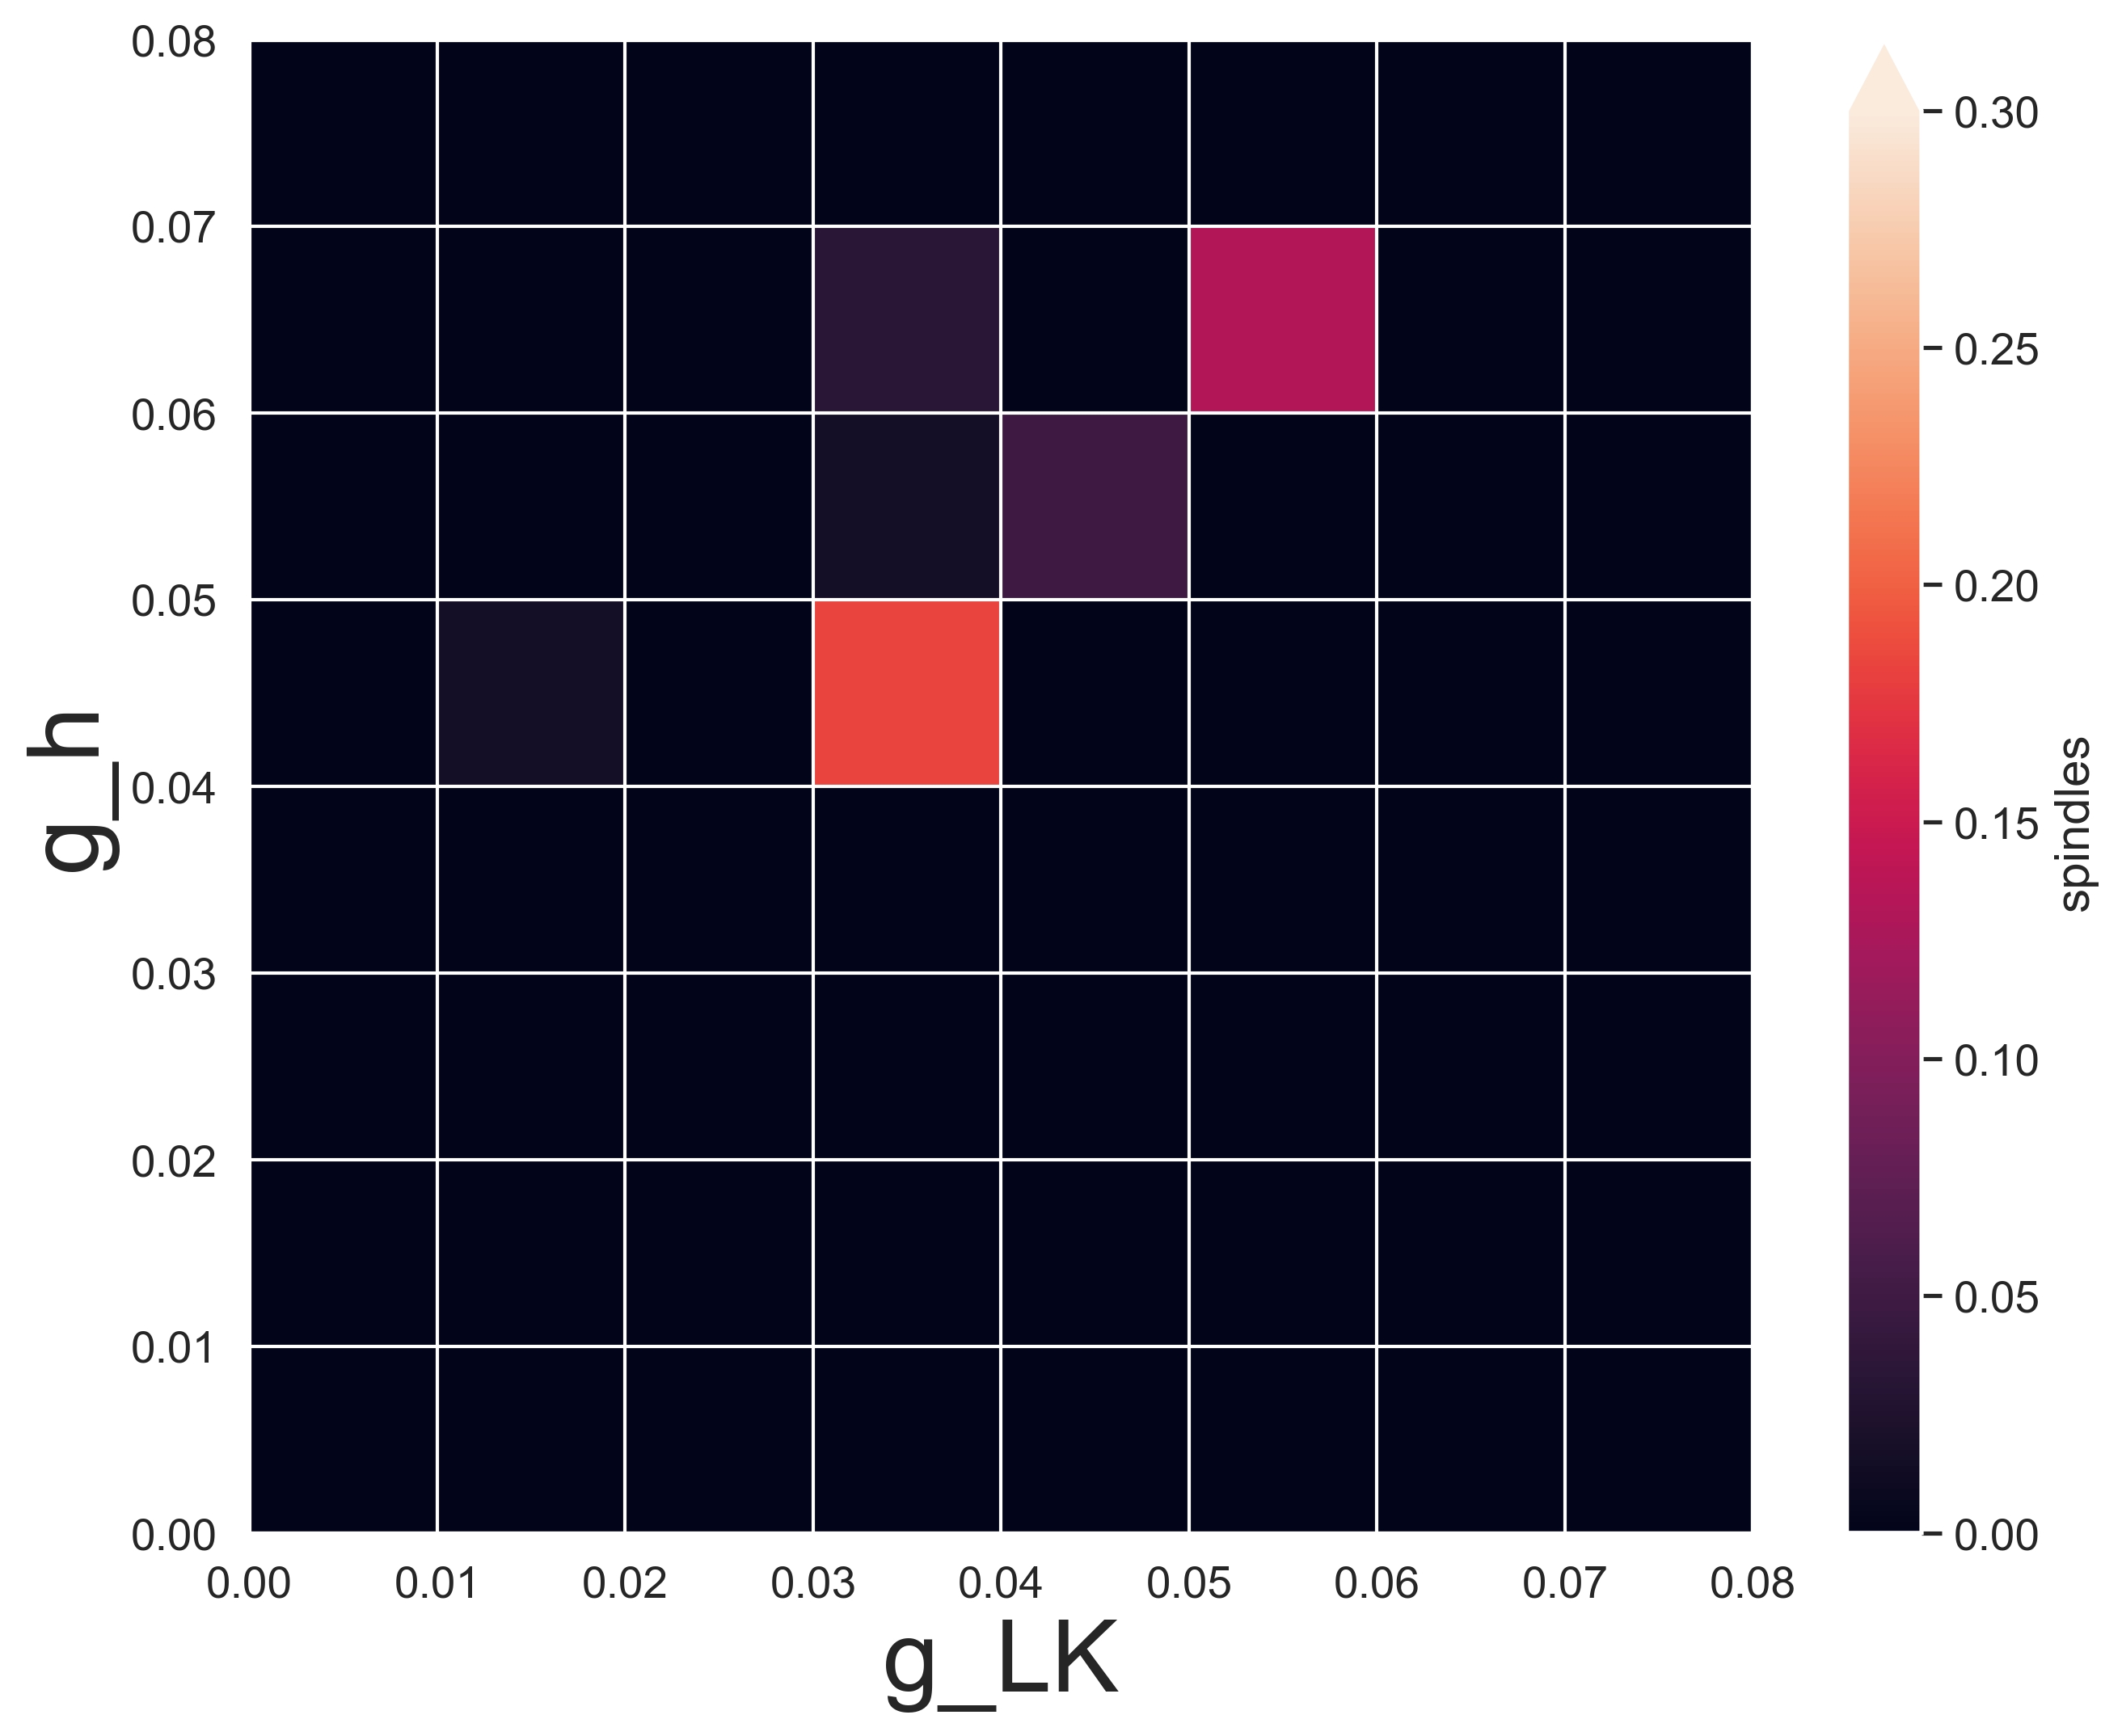

In [ ]:
import matplotlib.pyplot as plt

g_LK = np.unique(dfResults['g_LK'])
g_h = np.unique(dfResults['g_h'])
plot_results_matrix = np.reshape(plot_results, (len(g_LK), len(g_h)))

plt.figure(figsize=(10,8), dpi=300)
plt.imshow(plot_results_matrix, origin='lower', aspect='auto', extent=[g_LK[0], g_LK[-1], g_h[0], g_h[-1]])

plt.xlabel("g_LK", fontsize=30)
plt.ylabel("g_h", fontsize=30)
plt.clim(0, 0.3)
cbar = plt.colorbar(label="spindles", extend='max')
plt.show()

In [ ]:
# spindle detection
import yasa
import logging
def scale_to_voltage(dataarray, feature_range=(-80, -20)):
    data_scale = (feature_range[1]- feature_range[0]) / (
        dataarray.max(dim="time") - dataarray.min(dim="time")
    )
    data_min = feature_range[0] - dataarray.min(dim="time") * data_scale
    return data_scale * dataarray + data_min
def spindles_detect_thalamus(tcr_ts, trn_ts=None, trn_median_thresh=5.0, **kwargs):
    assert tcr_ts.ndim == 1, "Only works on 1D timeseries"
    if tcr_ts.max() < 10.0 or tcr_ts.std() < 5.0:
        logging.warning("No spindles found: STD too low")
        return None
    if trn_ts is not None and np.nanmedian(trn_ts) < trn_median_thresh:
        logging.warning("No spindles found: TRN is not oscillating")
        return None
    sf = float(1.0 / (tcr_ts.time[1] - tcr_ts.time[0]))
    return yasa.spindles_detect(
        scale_to_voltage(tcr_ts).values, sf=sf, **kwargs
    )


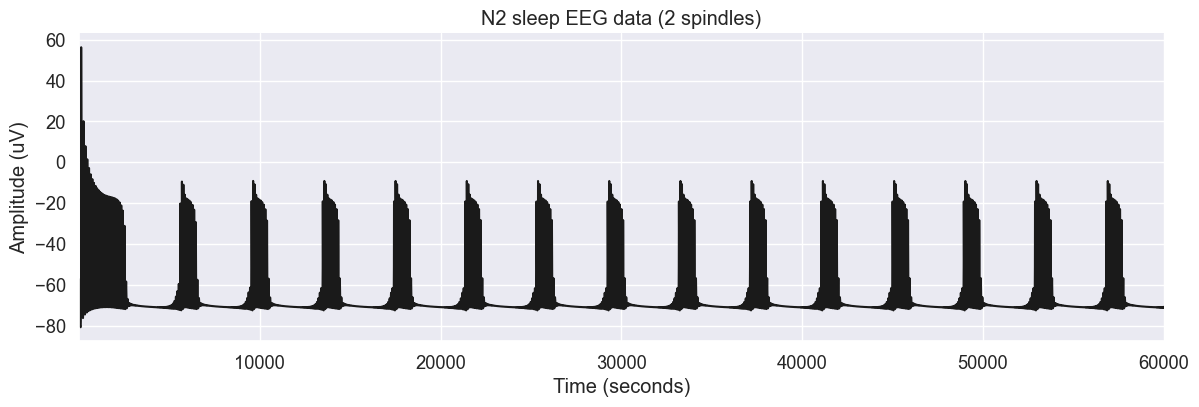

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
plt.plot(t, V_r[0][:-1], lw=1.5, color='k')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (uV)')
plt.xlim([t.min(), t.max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [ ]:
import yasa
import xarray as xr
# print(V_t)
print("V_t.shape:", V_t.shape)
data = np.diff(V_t[0]) * 1000  # pay attention to the unit(mV or uV)
# print(data)
print(data.shape)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(font_scale=1.2)

t1 = t[2000000:3000000] / 1000
print(t1.shape)
data1 = data[2000000:3000000]
print(data1.shape)


V_t.shape: (1, 6000001)
(6000000,)
(1000000,)
(1000000,)


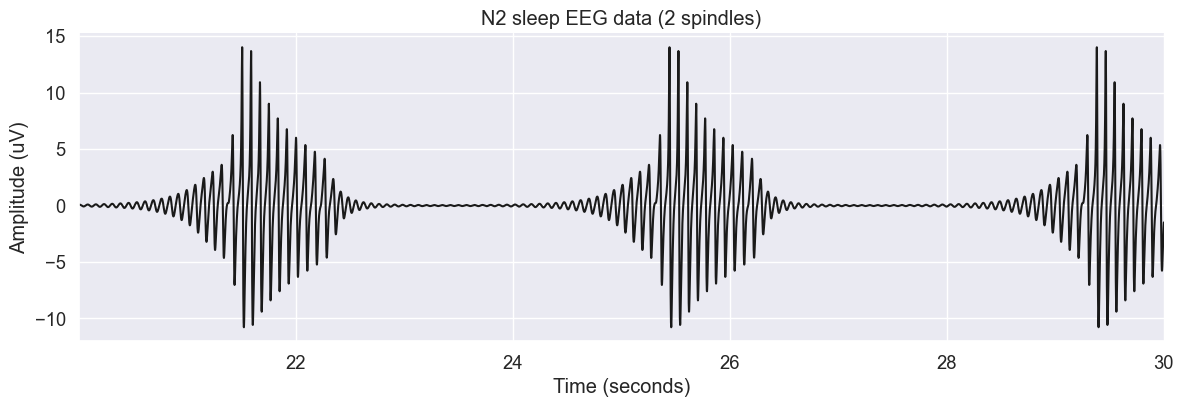

In [ ]:

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
plt.plot(t1, data1, lw=1.5, color='k')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (uV)')
plt.xlim([t1.min(), t1.max()])
plt.title('N2 sleep EEG data (2 spindles)')
sns.despine()

In [ ]:

coords = t1
# 7000
tcr_ts = xr.DataArray(data1, coords=[coords], dims=['time'])

sf = 100000 # !!!  1000,000 data for 10 seconds
sp = yasa.spindles_detect(tcr_ts, sf, duration=(0.3, 2))
sp.summary()



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished


,Start,Peak,End,Duration,Amplitude,RMS,AbsPower,RelPower,Frequency,Oscillations,Symmetry,Channel,IdxChannel
0,1.37993,1.58248,2.05855,0.67862,20.313875,4.494382,1.362862,0.433068,12.018875,8.0,0.298469,CHAN000,0
1,5.32165,5.52104,5.99368,0.67203,20.311624,4.516074,1.367935,0.433256,12.010448,8.0,0.296694,CHAN000,0
2,9.26283,9.45959,9.87499,0.61216,20.352317,4.625182,1.341527,0.432652,12.192349,8.0,0.321414,CHAN000,0


In [ ]:

import xarray as xr
data = traj.results.thalamus_results[0].V_t[0][:-1] *1000 # pay attention to the unit(mV or uV)
coords = traj.results.thalamus_results[0].t
# 7000
tcr_ts = xr.DataArray(data, coords=[coords], dims=['time'])

sf = 200
sp = yasa.spindles_detect(tcr_ts, sf)
sp.summary()


28-Nov-25 11:03:31 | ERROR | Wrong data amplitude for CHAN000 (trimmed STD = 0.006). Unit of data MUST be uV! Channel will be skipped.
28-Nov-25 11:03:31 | WARNING | All channels have bad amplitude. Returning None.


AttributeError: 'NoneType' object has no attribute 'summary'